In [1]:
import sys
from pathlib import Path
ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from scipy.optimize import root

s = Simulation()
N_t = 8000
tg = 250
tlist = np.linspace(0, tg, N_t)

100%|██████████| 2/2 [00:01<00:00,  1.30it/s]


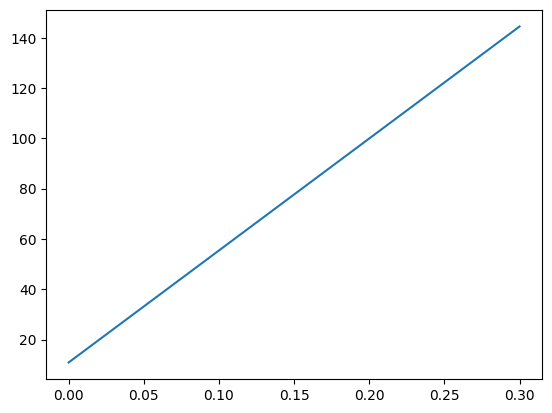

In [2]:
# plot optimal gate times aggainst amplitude
la = np.linspace(0, 0.3, 2) * 2*np.pi
ltg = []
linfid = []
for cos_amp in tqdm(la):
    # use resonant case
    cos_wd = s.find_resonance(cos_amp)
    time, fid, U = find_optimal_time(cos_wd, cos_amp, 3, s.state_a, s.state_b, s.state_c, s.E_array, s.V1_dressed_array, 300)
    linfid.append(1-fid)
    ltg.append(time)
plt.figure()
plt.plot(la / (2*np.pi), ltg, label='optimal gate time')
plt.show()


Now define a function that is capable for a given gate time to give the lowest possible amplitude to achieve that. 

In [ ]:
def find_lowest_amplitude_for_gate_time(target_time,
                                        amp_min=0.0,
                                        amp_max=0.3 * 2*np.pi,
                                        precision=20,
                                        max_eval=300):
    def get_gate_time(amp):
        wd = s.find_resonance(amp)
        time, optimal_f,_ = find_optimal_time(wd, amp, 3,
                                s.state_a, s.state_b, s.state_c,
                                s.E_array, s.V1_dressed_array,
                                max_eval)
        print("time: ", time,  "")
        return time
    
    left, right = amp_min, amp_max
    
    # Binary search: find boundary where gate_time <= target_time
    for _ in tqdm(range(precision)):
        mid = (left + right) / 2
        if get_gate_time(mid) > target_time:
            left = mid
        else:
            right = mid
    
    final_amp = right
    return final_amp

# Test mit verschiedenen Genauigkeiten
# result_fast = find_lowest_amplitude_for_gate_time(250, precision=10)
result_balanced = find_lowest_amplitude_for_gate_time(tg, precision=20)
# print(f"Fast (precision=10): {result_fast}")
print(f"Balanced (precision=20): {result_balanced}")

100%|██████████| 20/20 [00:17<00:00,  1.14it/s]

Balanced (precision=20): 0.22675437927246095


for a given gate time, we can now get the drive amplitude and because the drive amplitude defines the rabi rate in the case of resonant cos drive, we can get the rabi rate integral (which is tg * rate for constant Heff in the cos case)

rate:  (0.0024085073512958295+0j)


  0%|          | 0/24999 [00:00<?, ?it/s]

  0%|          | 0/24999 [00:00<?, ?it/s]

  0%|          | 0/24999 [00:00<?, ?it/s]

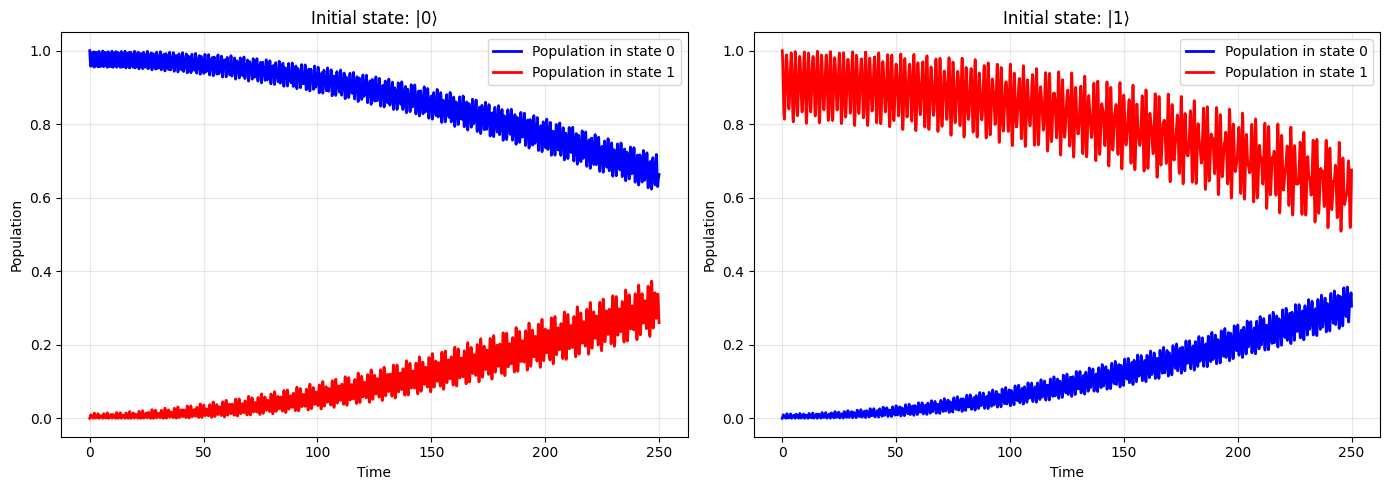

cos:  {'initial_state_0': 'state_0', 'pop_0_state_0': np.float64(0.6634253398664843), 'pop_1_state_0': np.float64(0.26019907002066067), 'pop_2_state_0': np.float64(0.07368844446114112), 'initial_state_1': 'state_1', 'pop_0_state_1': np.float64(0.3051817784015498), 'pop_1_state_1': np.float64(0.6754577005680416), 'pop_2_state_1': np.float64(0.017818761394183973), 'initial_state_2': 'state_2', 'pop_0_state_2': np.float64(0.02897110766733512), 'pop_1_state_2': np.float64(0.06260574973488547), 'pop_2_state_2': np.float64(0.9066009917807691), 'pop_0_to_1': np.float64(0.26019907002066067), 'pop_1_to_0': np.float64(0.3051817784015498), 'pop_2_final': np.float64(0.9066009917807691), 'iswap_fidelity': np.float64(0.28269042421110524)}
cos_wd:  0.7063314253604437  cos_amp:  0.036089080328946574
infidelity cos: 8.79e-01 pop: 7.17e-01


In [6]:
cos_amp = result_balanced
cos_wd = s.find_resonance(cos_amp)
# cos_amp, cos_wd = compute_cos_params(s, tg)
heff = s.heff(cos_wd, cos_amp)
rate = heff[0][1]
print("rate: ", rate)
time_integral = tg * rate.real
time_integral / (np.pi/2)

# find the gate fidelity for this
tlist_fid = np.linspace(0, tg, 25000)
lh = [s.H0_dressed, [s.V1_dressed, lambda t, args: cos_amp * np.cos(cos_wd * t)]]
f_cos = extract_fidelity(lh, tlist_fid, sim=s)
fpop_cos = extract_pop_fid(lh, tlist_fid, sim=s, plot=True)
print("cos: ", fpop_cos)
print("cos_wd: ", cos_wd/(2*np.pi), " cos_amp: ", cos_amp/(2*np.pi))
print(f"infidelity cos: {(1-f_cos):.2e} pop: {(1-fpop_cos['iswap_fidelity']):.2e}")
